# 项目名称 — 模块说明

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-B2_美联储货币政策与全球资产价格传导 |
| 小组   | 第 4 组 |
| 成员   | 25210227 荣渝渝| 25210229 沈仕沐| 25210246 王丽娜| 25210257 吴玥| 25210271 连伊丽| 25210275 薛佳程| 25210285 易忠凯|
| GitHub | https://github.com/zhongerhenglu/ds2026-G04-T-B2_FedPolicyAssets |
| Pages  | https://zhongerhenglu.github.io/ds2026-G04-T-B2_FedPolicyAssets/ |
| 日期   | 2026-05-16 |

# 连伊丽：任务 3c — 2022 加息周期资产表现特写可视化

图表已保存到 output/fig_assets_in_cycles.png


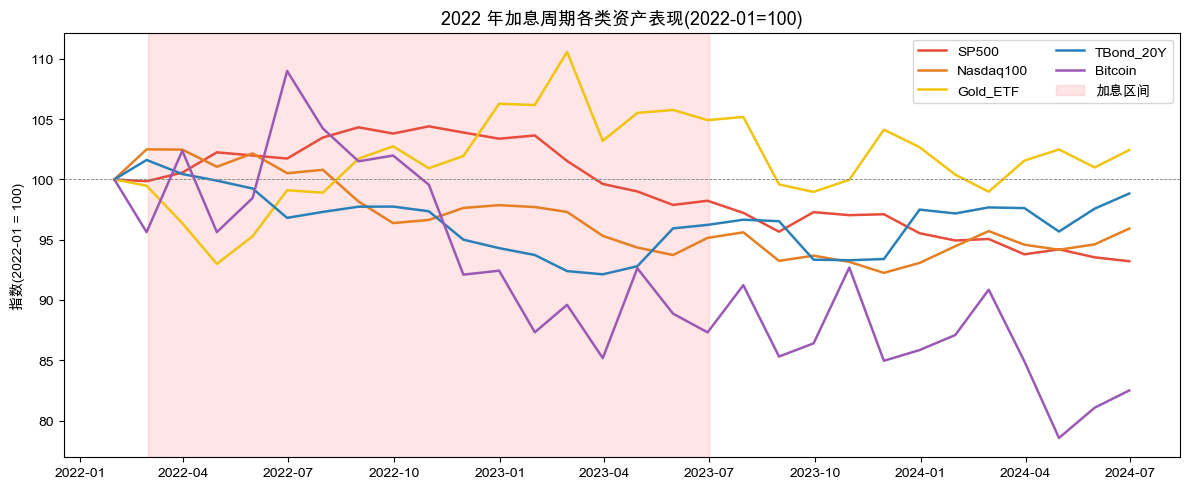

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 中文字体配置，避免标题和坐标文字显示方块
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'STHeiti', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

# 读取资产数据（假设从01_get_data获取）
assets = pd.read_csv('data_raw/assets_raw.csv', index_col=0, parse_dates=True)

# 中文字体配置，避免标题和坐标文字显示方块
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'STHeiti', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

# 资产列
asset_cols = ['SP500', 'Nasdaq100', 'Gold_ETF', 'TBond_20Y', 'Bitcoin']

# 切片2022-01到2024-06
recent = assets['2022-01':'2024-06'][asset_cols].copy()

# 归一化到基期=100
recent_norm = recent / recent.iloc[0] * 100

# 绘制
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2980b9', '#9b59b6']
for col, color in zip(asset_cols, colors):
    if col in recent_norm.columns:
        ax.plot(recent_norm.index, recent_norm[col], label=col, color=color, linewidth=1.8)

ax.axhline(100, color='gray', linewidth=0.6, linestyle='--')
ax.axvspan('2022-03', '2023-07', alpha=0.1, color='red', label='加息区间')
ax.set_title('2022 年加息周期各类资产表现(2022-01=100)', fontsize=13)
ax.set_ylabel('指数(2022-01 = 100)')
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig('output/fig_assets_in_cycles.png', dpi=150)
print('图表已保存到 output/fig_assets_in_cycles.png')